### Coding Assistant with LangChain, LangGraph and Azure OpenAI


In [92]:
PROJECT_ID = 7954997
MONGODB_DOCUMENT_ID = "68c546bedcdcf56f65e1a4e0"

In [93]:
import os
from dotenv import load_dotenv

load_dotenv()
MONGODB_URI = os.getenv("MONGODB_URI")

In [94]:
from pymongo import MongoClient

client = MongoClient(MONGODB_URI)
print(client.server_info())

print("Connected to Mongo DB")

collection = client["opensolar_db"]["project"]
print(collection)

{'version': '8.0.15', 'gitVersion': 'f79b970f08f60c41491003cd55a3dd459a279c39', 'modules': ['enterprise'], 'allocator': 'tcmalloc-google', 'javascriptEngine': 'mozjs', 'sysInfo': 'deprecated', 'versionArray': [8, 0, 15, 0], 'bits': 64, 'debug': False, 'maxBsonObjectSize': 16777216, 'storageEngines': ['devnull', 'inMemory', 'queryable_wt', 'wiredTiger'], 'ok': 1.0, '$clusterTime': {'clusterTime': Timestamp(1760280268, 1), 'signature': {'hash': b'\x9fQ%a\xc8\xbeAk5\xb6\x7f\xbe\xbcb\xcc\xde\x99\x972\xe6', 'keyId': 7500256948978188295}}, 'operationTime': Timestamp(1760280268, 1)}
Connected to Mongo DB
Collection(Database(MongoClient(host=['ac-pd9xhlm-shard-00-02.jmdonyw.mongodb.net:27017', 'ac-pd9xhlm-shard-00-00.jmdonyw.mongodb.net:27017', 'ac-pd9xhlm-shard-00-01.jmdonyw.mongodb.net:27017'], document_class=dict, tz_aware=False, connect=True, authsource='admin', replicaset='atlas-11s7i4-shard-0', tls=True), 'opensolar_db'), 'project')


{'access': 2, 'events': ['https://api.opensolar.com/api/orgs/178878/events/39879463/', 'https://api.opensolar.com/api/orgs/178878/events/39880151/', 'https://api.opensolar.com/api/orgs/178878/events/39880156/', 'https://api.opensolar.com/api/orgs/178878/events/40198325/', 'https://api.opensolar.com/api/orgs/178878/events/40198333/', 'https://api.opensolar.com/api/orgs/178878/events/40198363/', 'https://api.opensolar.com/api/orgs/178878/events/40198366/', 'https://api.opensolar.com/api/orgs/178878/events/40198374/', 'https://api.opensolar.com/api/orgs/178878/events/40198384/', 'https://api.opensolar.com/api/orgs/178878/events/40198400/', 'https://api.opensolar.com/api/orgs/178878/events/40198401/', 'https://api.opensolar.com/api/orgs/178878/events/40198404/', 'https://api.opensolar.com/api/orgs/178878/events/40198407/', 'https://api.opensolar.com/api/orgs/178878/events/40198416/', 'https://api.opensolar.com/api/orgs/178878/events/40198419/', 'https://api.opensolar.com/api/orgs/178878/ev
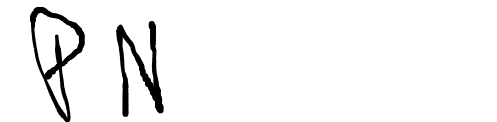

In [95]:
from bson import ObjectId


doc = collection.find_one({"_id": ObjectId(MONGODB_DOCUMENT_ID)}, {"_id": 0})
print(doc)

'{"access": 2, "events": ["https://api.opensolar.com/api/orgs/178878/events/39879463/", "https://api.opensolar.com/api/orgs/178878/events/39880151/", "https://api.opensolar.com/api/orgs/178878/events/39880156/", "https://api.opensolar.com/api/orgs/178878/events/40198325/", "https://api.opensolar.com/api/orgs/178878/events/40198333/", "https://api.opensolar.com/api/orgs/178878/events/40198363/", "https://api.opensolar.com/api/orgs/178878/events/40198366/", "https://api.opensolar.com/api/orgs/178878/events/40198374/", "https://api.opensolar.com/api/orgs/178878/events/40198384/", "https://api.opensolar.com/api/orgs/178878/events/40198400/", "https://api.opensolar.com/api/orgs/178878/events/40198401/", "https://api.opensolar.com/api/orgs/178878/events/40198404/", "https://api.opensolar.com/api/orgs/178878/events/40198407/", "https://api.opensolar.com/api/orgs/178878/events/40198416/", "https://api.opensolar.com/api/orgs/178878/events/40198419/", "https://api.opensolar.com/api/orgs/178878/e
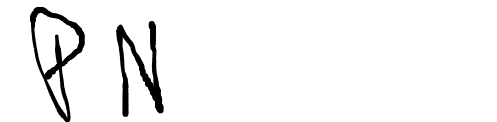

In [96]:
import json

project = json.dumps(doc)
project

In [97]:
from langchain.text_splitter import RecursiveCharacterTextSplitter

chunks = RecursiveCharacterTextSplitter(
    chunk_size=1000, chunk_overlap=200, separators=["\n", "", " "]
).split_text(project)

print(f"Total Chunks: {len(chunks)}")

Total Chunks: 307


In [98]:
from langchain_openai import AzureOpenAIEmbeddings

embeddings = AzureOpenAIEmbeddings(
    api_key=os.getenv("AZURE_OPENAI_EMBEDDING_API_KEY"),
    azure_endpoint=os.getenv("AZURE_OPENAI_EMBEDDING_ENDPOINT"),
    azure_deployment=os.getenv("AZURE_OPENAI_EMBEDDING_DEPLOYMENT"),
    api_version=os.getenv("AZURE_OPENAI_EMBEDDING_API_VERSION"),
    model=os.getenv("AZURE_OPENAI_EMBEDDING_MODEL_NAME"),
    chunk_size=len(chunks),
)
embeddings.model

'text-embedding-3-large'

In [99]:
from langchain.vectorstores import Chroma

retriever = Chroma.from_texts(texts=chunks, embedding=embeddings).as_retriever(
    search_kwargs={"k": 3}
)

In [100]:
from pydantic import BaseModel, Field


class Code(BaseModel):
    """Schema for code solutions from the coding assistant"""

    prefix: str = Field(description="Description of the problem and approach")
    imports: str = Field(description="Code block import statements")
    code: str = Field(description="Code block not including import statement")

In [101]:
system_prompt = "\n".join(
    [
        "You are an python coding assistant with expertise in AI, ML, Generative AI, Agentic AI, Aamzon Web Services (AWS), Structured Query Language (PostgreSQL) and NoSQL (MongoDB)",
        "-----------------------\n\n{context}\n\n-----------------------"
        "Answer the user question relevent to the data provided by the user",
        "Ensure any code you provided can be executed with all required imports and variables defined",
        "Structure your answer with a description of the code solution",
        "Then list the imports and finally list the functioning code block",
    ]
)

system_prompt

'You are an python coding assistant with expertise in AI, ML, Generative AI, Agentic AI, Aamzon Web Services (AWS), Structured Query Language (PostgreSQL) and NoSQL (MongoDB)\n-----------------------\n\n{context}\n\n-----------------------Answer the user question relevent to the data provided by the user\nEnsure any code you provided can be executed with all required imports and variables defined\nStructure your answer with a description of the code solution\nThen list the imports and finally list the functioning code block'

In [102]:
from langchain.prompts import ChatPromptTemplate

prompt = ChatPromptTemplate.from_messages(
    [("system", system_prompt), ("placeholder", "{messages}")]
)

In [103]:
from langchain_openai import AzureChatOpenAI

llm = AzureChatOpenAI(
    api_key=os.getenv("AZURE_OPENAI_CHAT_API_KEY"),
    azure_endpoint=os.getenv("AZURE_OPENAI_CHAT_ENDPOINT"),
    azure_deployment=os.getenv("AZURE_OPENAI_CHAT_DEPLOYMENT"),
    api_version=os.getenv("AZURE_OPENAI_CHAT_API_VERSION"),
    model=os.getenv("AZURE_OPENAI_CHAT_MODEL_NAME"),
    temperature=0,
)
llm.model_name

'gpt-4.1'

In [104]:
chain = prompt | llm.with_structured_output(Code)

In [105]:
question = """How do you design a relational database schema from a JSON data for a Solar Energy Project. 
The relational database is PostgreSQL. Provide the full indepth SQL script.
Also write a seperate data ingestion python script using Peewee"""

In [106]:
response = chain.invoke({"context": retriever, "messages": [("user", question)]})
response

Code(prefix='To design a relational schema from JSON data for a Solar Energy Project, you first analyze the JSON structure, identify entities (tables), their attributes (columns), and relationships (foreign keys). Common entities might include Projects, Sites, Panels, Sensors, and Measurements. Below, I provide a sample JSON, a normalized PostgreSQL schema, and a Python data ingestion script using Peewee ORM.', imports='# SQL: No imports needed\n# Python:\nfrom peewee import *\nimport json\n', code='# 1. Example JSON structure\n# (You can adapt this to your actual data)\nexample_json = \'\'\'\n{\n  "project_name": "Solar Farm Alpha",\n  "location": "Nevada, USA",\n  "sites": [\n    {\n      "site_name": "Site 1",\n      "latitude": 36.1699,\n      "longitude": -115.1398,\n      "panels": [\n        {\n          "panel_id": "PANEL-001",\n          "type": "Monocrystalline",\n          "capacity_kw": 5.0,\n          "sensors": [\n            {\n              "sensor_id": "SEN-001",\n    

In [107]:
response.prefix

'To design a relational schema from JSON data for a Solar Energy Project, you first analyze the JSON structure, identify entities (tables), their attributes (columns), and relationships (foreign keys). Common entities might include Projects, Sites, Panels, Sensors, and Measurements. Below, I provide a sample JSON, a normalized PostgreSQL schema, and a Python data ingestion script using Peewee ORM.'

In [108]:
response.imports

'# SQL: No imports needed\n# Python:\nfrom peewee import *\nimport json\n'

In [109]:
response.code

'# 1. Example JSON structure\n# (You can adapt this to your actual data)\nexample_json = \'\'\'\n{\n  "project_name": "Solar Farm Alpha",\n  "location": "Nevada, USA",\n  "sites": [\n    {\n      "site_name": "Site 1",\n      "latitude": 36.1699,\n      "longitude": -115.1398,\n      "panels": [\n        {\n          "panel_id": "PANEL-001",\n          "type": "Monocrystalline",\n          "capacity_kw": 5.0,\n          "sensors": [\n            {\n              "sensor_id": "SEN-001",\n              "type": "Temperature",\n              "measurements": [\n                {"timestamp": "2024-06-01T10:00:00Z", "value": 35.2},\n                {"timestamp": "2024-06-01T11:00:00Z", "value": 36.1}\n              ]\n            }\n          ]\n        }\n      ]\n    }\n  ]\n}\n\'\'\'\n\n# 2. PostgreSQL Schema (SQL Script)\n# ----------------------------------\n# Save this as solar_schema.sql and run in psql\nsql_schema = \'\'\'\nCREATE TABLE projects (\n    id SERIAL PRIMARY KEY,\n    proj

In [110]:
from typing import List

from typing_extensions import TypedDict


class State(TypedDict):
    error: bool
    messages: List
    generation: Code
    iterations: int = 0

In [111]:
max_iterations = 3
reflect = True

In [112]:
def code_generation(state: State):
    """
    Generate Code Solution

    Args:
        state (dict): The current Graph State
    Returns:
        state (dict): New key added to state, generation
    """
    print("----- CODE GENERATION-----")

    messages = state["messages"]
    iterations = state["iterations"]
    error = state["error"]

    if error:
        messages += [
            (
                "user",
                "Now try again, Invoke the code tool to structure the output with a prefix, import and code block",
            )
        ]
    res: Code = chain.invoke({"context": retriever, "messages": messages})

    messages += [
        ("assistant", f"{res.prefix}\nImports: {res.imports}\nCode: {res.code}")
    ]

    iterations += 1
    return {"generation": res, "messages": messages, "iterations": iterations}

In [113]:
def code_checking(state: State):
    """
    Check Generated Code

    Args:
        state (dict): The current Graph State
    Returns:
        state (dict): New key added to state, error
    """
    print("----- CODE CHECKING-----")

    messages = state["messages"]
    generated_code = state["generation"]
    iterations = state["iterations"]

    imports = generated_code.imports
    code = generated_code.code

    try:
        exec(imports)
    except Exception as e:
        print("----- CODE IMPORT CHECK FAILED -----")
        messages += [("user", f"Your generated code failed the import test: {str(e)}")]
        return {
            "generation": generated_code,
            "messages": messages,
            "iterations": iterations,
            "error": True,
        }
    try:
        exec(imports + "\n" + code)
    except Exception as e:
        print("----- CODE BLOCK CHECK FAILED -----")
        messages += [
            ("user", f"Your generated code failed the execution test: {str(e)}")
        ]
        return {
            "generation": generated_code,
            "messages": messages,
            "iterations": iterations,
            "error": True,
        }

    print("----- NO CODE TEST FAILURE -----")
    return {
        "generation": generated_code,
        "messages": messages,
        "iterations": iterations,
        "error": False,
    }

In [114]:
def reflect_on_error(state: State):
    """
    Generate Code Solution

    Args:
        state (dict): The current Graph State
    Returns:
        state (dict): New key added to state, generation
    """
    print("----- CODE GENERATION AND ANALYZING ERRORS -----")

    messages = state["messages"]
    iterations = state["iterations"]
    generated_code = state["generation"]

    res = chain.invoke({"context": retriever, "messages": messages})

    messages += [("assistant", f"Here are the reflections on the error: {res}")]
    return {
        "generation": generated_code,
        "messages": messages,
        "iterations": iterations,
    }

In [115]:
def decide_to_finish(state: State):
    """
    Determine whether to finish

    Args:
        state (dict): The current Graph State
    Returns:
        str: Next node to call
    """
    print("----- TOOL CONDITIONS -----")

    error = state["error"]
    iterations = state["iterations"]

    if error == False or iterations == max_iterations:
        print("----- DECISION: FINISH -----")
        return "end"
    else:
        print("----- DECISION: RETRY CODE GENERATION -----")
        if reflect:
            return "reflect_on_error"
        else:
            return "code_generation"

In [116]:
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.graph import END, START, StateGraph

memory = InMemorySaver()
config = {"configurable": {"thread_id": "1"}}

builder = StateGraph(State)

builder.add_node("code_generation", code_generation)
builder.add_node("code_checking", code_checking)
builder.add_node("reflect_on_error", reflect_on_error)

builder.add_edge(START, "code_generation")
builder.add_edge("code_generation", "code_checking")
builder.add_conditional_edges(
    "code_checking",
    decide_to_finish,
    {
        "end": END,
        "reflect_on_error": "reflect_on_error",
        "code_generation": "code_generation",
    },
)
builder.add_edge("reflect_on_error", "code_generation")

graph = builder.compile(checkpointer=memory)

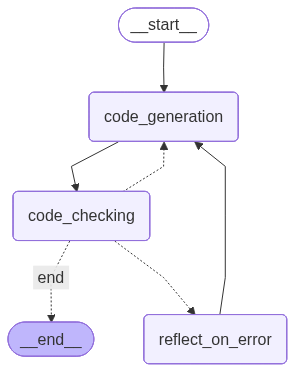

In [117]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [118]:
response = graph.invoke(
    {"messages": [("user", question)], "iterations": 0, "error": False}, config=config
)

response

----- CODE GENERATION-----
----- CODE CHECKING-----
----- CODE IMPORT CHECK FAILED -----
----- TOOL CONDITIONS -----
----- DECISION: RETRY CODE GENERATION -----
----- CODE GENERATION AND ANALYZING ERRORS -----
----- CODE GENERATION-----
----- CODE CHECKING-----
----- CODE IMPORT CHECK FAILED -----
----- TOOL CONDITIONS -----
----- DECISION: RETRY CODE GENERATION -----
----- CODE GENERATION AND ANALYZING ERRORS -----
----- CODE GENERATION-----
----- CODE CHECKING-----
----- CODE IMPORT CHECK FAILED -----
----- TOOL CONDITIONS -----
----- DECISION: FINISH -----


{'error': True,
 'messages': [('user',
   'How do you design a relational database schema from a JSON data for a Solar Energy Project. \nThe relational database is PostgreSQL. Provide the full indepth SQL script.\nAlso write a seperate data ingestion python script using Peewee'),
  ('assistant',
   'To design a relational schema from JSON data for a Solar Energy Project, you first analyze the JSON structure, identify entities (tables), their attributes (columns), and relationships (foreign keys). Common entities might include Projects, Sites, Panels, Sensors, and Readings. Below, I provide a sample JSON, a normalized PostgreSQL schema, and a Python data ingestion script using Peewee ORM.\nImports: import json\nfrom peewee import *\nfrom datetime import datetime\nCode: # 1. Example JSON structure\n# (You can adapt this to your actual data)\nexample_json = {\n    "project_name": "Solar Farm Alpha",\n    "location": "California",\n    "sites": [\n        {\n            "site_name": "Site 

In [119]:
print(response["generation"].prefix)

The error 'No module named peewee' occurs because the Peewee ORM is not installed in your Python environment. To resolve this, you must first install Peewee using pip. After installation, you can import and use it in your scripts. Below are the steps: (1) install Peewee, (2) import it, and (3) proceed with your code.


In [120]:
print(response["generation"].imports, sep="\n")

# Step 1: Install Peewee using pip (uncomment and run in your terminal or notebook)
# !pip install peewee

# Step 2: Import Peewee
from peewee import *


In [121]:
print(response["generation"].code, sep="\n")

# Step 3: Now you can use Peewee in your code
# Example:
# db = PostgresqlDatabase('solar_db', user='postgres', password='yourpassword', host='localhost', port=5432)
# class BaseModel(Model):
#     class Meta:
#         database = db
# ... (rest of your code here)

